这个是重叠数据，用于筛选变量后续构建MSEM

In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myrfecv as mr

path_data_raw = "C:/Users/dell/OneDrive/file/"
path_country_nc = "C:/Users/dell/OneDrive/file/nc"
path_onedrive_csv = "C:/Users/dell/OneDrive/file/csv/"
path_one_spdb = 'C:/Users/dell/OneDrive/file/SPDB/'
drive_letter = 'E:'

path_pre = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/pretreatment/"
path_match = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/match/"

path_2_preanalysis_data = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part2_analysis/preanalysis/"


path_temp = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/temp/"


meta_name = "meta_data.csv"

path_lrsw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/lrsw_forecast/'
path_lrsw_rfecv_fig = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/fig/'

GBDT Optimal number of features: 40
RF Optimal number of features: 43
LGBM Optimal number of features: 52


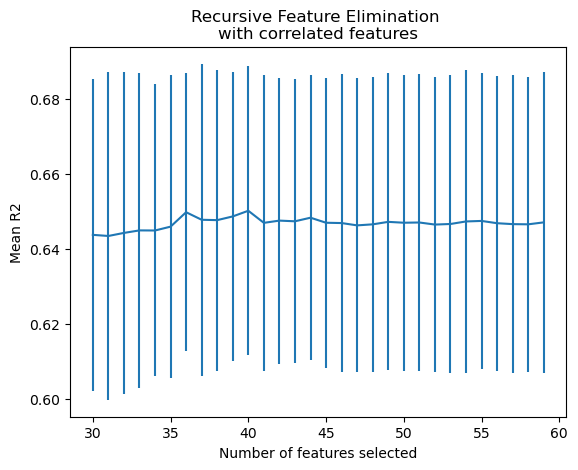

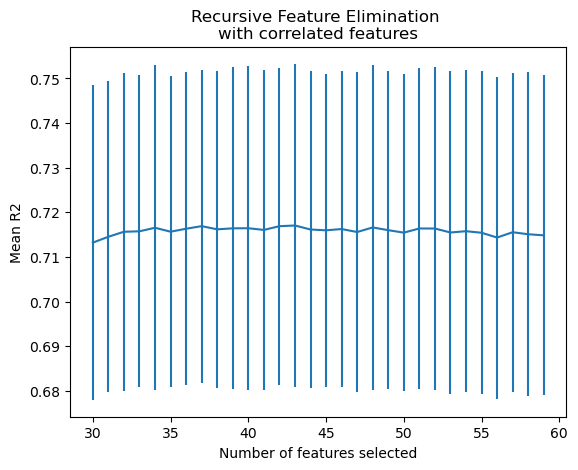

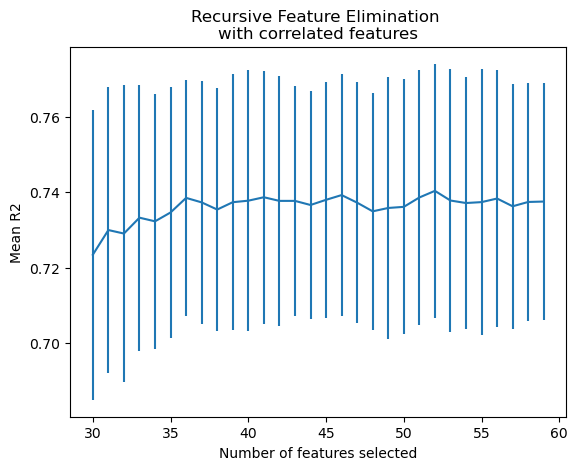

In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
dict_clf = {
    'GBDT': GradientBoostingRegressor(random_state=202406),
    'RF': RandomForestRegressor(random_state=202406),
    'LGBM': LGBMRegressor(random_state=202406)
}
str_prefix = 'lr_sw'

df_lrsw_data = pd.read_csv(path_match + "lr_sw_match_treat_full.csv")

df_lrsw_data['year'] = (df_lrsw_data['year'] - 2000) / (2020 - 2000)

columns_to_drop = ['lon_grid', 'lat_grid', 'posname']
df_lrsw_data = df_lrsw_data.drop(columns=columns_to_drop)

for key, clf in dict_clf.items():
    mr.start_rfecv(key, clf, df_lrsw_data, str_prefix, path_lrsw_rfecv_data, path_lrsw_rfecv_fig, 'cv')

In [ ]:
df_lgbm = pd.read_csv(path_lrsw_rfecv_data + 'lr_sw_rfecv_features_LGBMcv.csv')
df_lgbm['Importance'] = df_lgbm['Importance'] / df_lgbm['Importance'].sum()
df_lgbm.to_csv(path_lrsw_rfecv_data + 'lr_sw_rfecv_features_LGBMcv.csv', index=False)

In [ ]:
df_lrsw_rf_rfecv = pd.read_csv(path_lrsw_rfecv_data + str_prefix + '_rfecv_r2_RFcv.csv')
df_lrsw_rf_rfecv['model'] = 'RF'
df_lrsw_gbdt_rfecv = pd.read_csv(path_lrsw_rfecv_data + str_prefix + '_rfecv_r2_GBDTcv.csv')
df_lrsw_gbdt_rfecv['model'] = 'GBDT'
df_lrsw_lgbm_rfecv = pd.read_csv(path_lrsw_rfecv_data + str_prefix + '_rfecv_r2_LGBMcv.csv')
df_lrsw_lgbm_rfecv['model'] = 'LGBM'

df_lrsw_rfecv = pd.concat([df_lrsw_rf_rfecv,df_lrsw_gbdt_rfecv, df_lrsw_lgbm_rfecv],axis=0)

df_lrsw_rfecv = df_lrsw_rfecv.sort_values(by='mean_test_score', ascending=False)
max_index = df_lrsw_rfecv['mean_test_score'].idxmax()
min_features = df_lrsw_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_lrsw_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_lrsw_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_lrsw_rfecv.to_csv(path_lrsw_rfecv_data + str_prefix +'_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')


model:LGBM min_feature:52 score:0.74


这个到这就可以了不用去找超参